In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from plot_openloop import plot_openloop
from plot_estimator import plot_estimator

from matplotlib.animation import FuncAnimation

plt.rcParams.update({'font.size': 18})


#plotting colors from plot_estimator.py
MCcolors = {
    "blue":   np.array([4, 51, 255]) / 255,
    "purple": np.array([147, 23, 255]) / 255,
    "green":  np.array([0, 160, 0]) / 255,
    "red":    np.array([200, 0, 0]) / 255,
    "mag":    np.array([255, 64, 255]) / 255,
}

\begin{align}
    \dot p = \bar\beta(1+x)(1-p)p - \delta p\\
    \tau_x\dot x = -x + \tanh\left((k_p p + k_x x^2 + u_0)x\right)
\end{align}

define the dynamics:

expiriments:

- flip observation to x instead of p (WORKING)
- add noise to beta (WORKING)
- deterministic beta but varying in time (WORKING)
- like SIS dynamics (bias near zero?) - just use existing code with smaller $\bar\beta$ so (WORKING)

In [2]:
def SIS_NOD(t, y, beta,delta,kp,kx,u0,tau,w):
    p = y[0]#max(0, min(1, y[0])) # keep everything bounded
    x = y[1]#max(-1, min(1, y[1]))
    pdot = beta*(1+x)*(1-p)*p - delta*p
    xdot = (-x +np.tanh((kp*p + kx*x*x + u0)*x)+w)/tau

    return [pdot,xdot] 

def percent_out(t, xest, Pest, x_true):
    bd = np.squeeze(Pest)
    upper = xest + 2 * np.sqrt(bd)
    lower = xest - 2 * np.sqrt(bd)

    out_loc = np.where((x_true > upper) | (x_true < lower))[0]

    return len(out_loc)/len(t)

Define parameters, initial condition, bifurcation points (from theory and numerical continuation), run a simulation without noise to make sure everything works:

0.3 0.36974549 0.5250000000000001


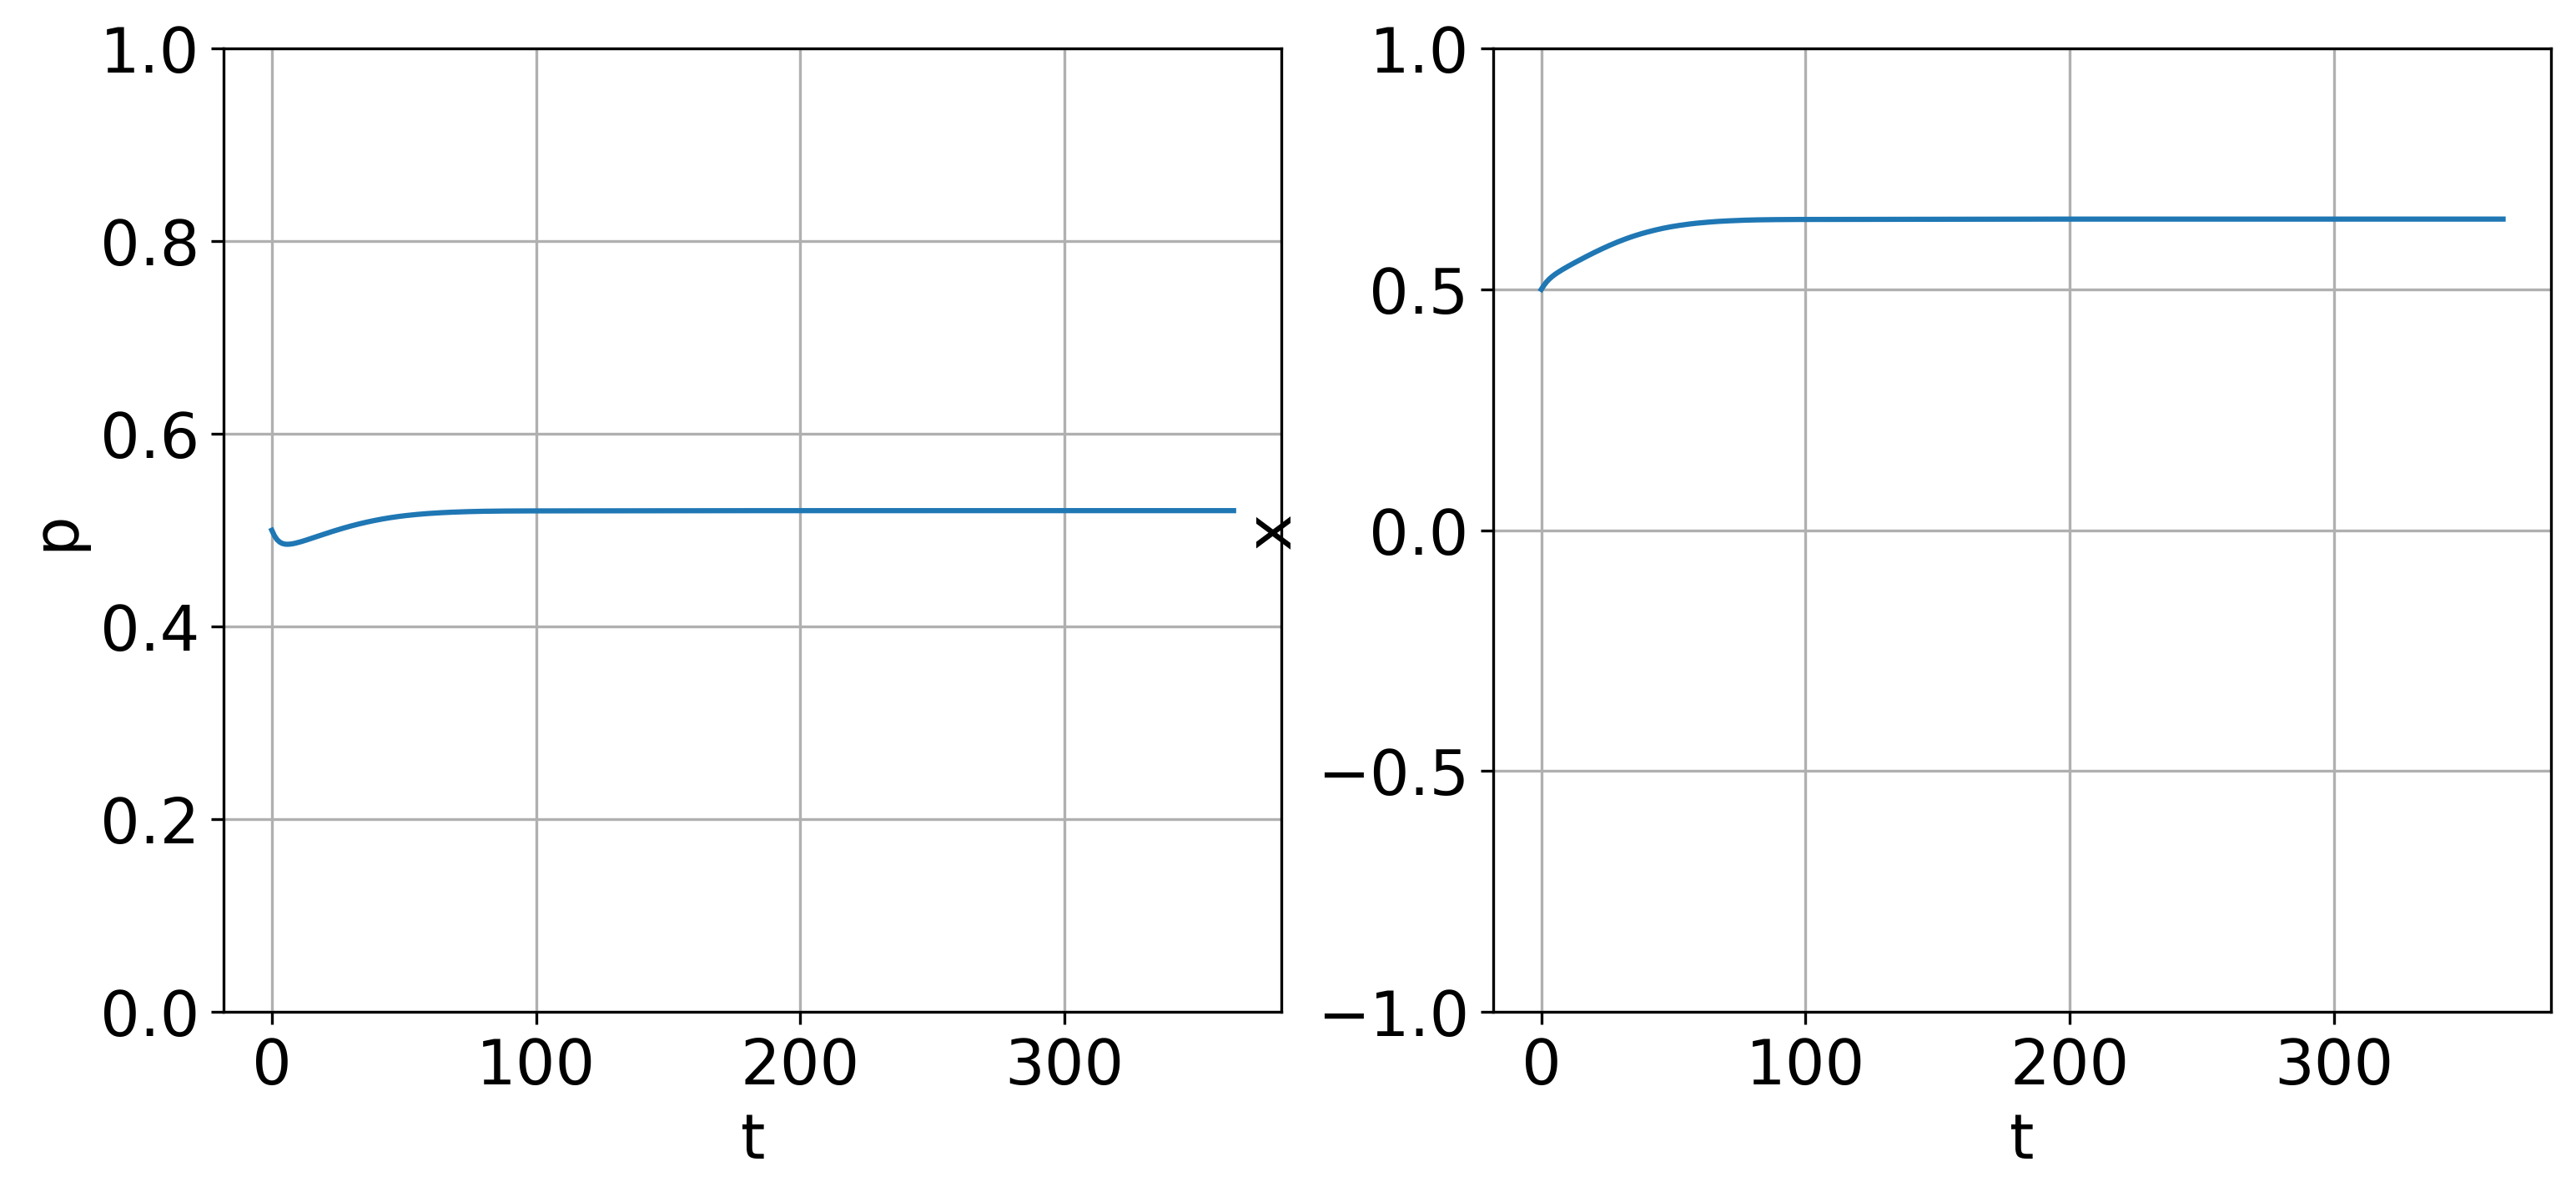

In [3]:
delta = 0.3
kp = 0.7
kx = 0.3
u0 = 0.7
tau = 1
w = 0

betastar = delta*kp/(kp-1+u0)

# bifurcation points
bp1 = delta
bp2 = 0.36974549
bp3 = betastar

print(bp1,bp2,bp3)

beta = 0.38 # for drop simulation
#beta = 0.2 # for SIS like simulation

y0 = [0.5,0.5]

tspan = [0,365]
dt = 1.0
t_eval = np.arange(tspan[0],tspan[1],dt)
sol = solve_ivp(SIS_NOD,tspan,y0,args = (beta,delta,kp,kx,u0,tau,w),t_eval = t_eval,method = "LSODA")

fig,ax = plt.subplots(1,2,figsize = (12,5),dpi = 300)
ax[0].plot(sol.t,sol.y[0])
ax[0].set_xlabel("t")
ax[0].set_ylabel("p")
ax[0].set_ylim(0,1)
ax[0].grid()

ax[1].plot(sol.t,sol.y[1])
ax[1].set_xlabel("t")
ax[1].set_ylabel("x")
ax[1].set_ylim(-1,1)
ax[1].grid()

plt.show()

In [4]:
def predict_state_SIS_NOD(Yk, Wk, beta,delta,kp,kx,u0,tau, dt):
    nx, N = Yk.shape
    Ykp1 = np.zeros_like(Yk)

    for i in range(N):
        y0 = Yk[:, i]
        w  = Wk[0, i]
        
        sol = solve_ivp(
            SIS_NOD,
            [0, dt],
            y0,
            args = (beta,delta,kp,kx,u0,tau,w),
            method='LSODA'
        )

        Ykp1[:, i] = sol.y[:, -1]
        Ykp1[0, i] = np.clip(Ykp1[0, i], 0, 1) # keep everything bounded (try outside of ODE)
        Ykp1[1, i] = np.clip(Ykp1[1, i], -1, 1)

    return Ykp1

In [5]:
# generate measurements
rng = np.random.default_rng(10)
t = t_eval
tf = t[-1]
nt = len(t)

# Process noise

wstd = 0.02
Qc = wstd**2 # sqrt of this is sigma/std of w
w = rng.standard_normal(nt) * np.sqrt(Qc*dt)

# Simulate dynamics
y0 = [0.5,0.5]
ny = 2
y_true = np.zeros((ny, nt))
y_true[:, 0] = y0

for k in range(nt - 1):
    y_init = y_true[:, k]
    wk = w[k]
    tspan_small = [t[k], t[k + 1]]
    sol = solve_ivp(SIS_NOD, tspan_small, y_init, args=(beta,delta,kp,kx,u0,tau,wk), method='LSODA')
    y_true[:, k + 1] = sol.y[:, -1]
    y_true[0,k+1] = np.clip(y_true[0,k+1],0,1)
    y_true[1,k+1] = np.clip(y_true[1,k+1],-1,1)

# Noisy measurements
vstd = 0.1
R = vstd**2 # sqrt of this is sigma of v
mu = -0.05
v = np.sqrt(R) * rng.standard_normal(nt) + mu
z = y_true[0, :] + v
# restrict to domain of problem
z[z<0]=0
z[z>1]=1

# ── Open-loop plots ──────────────────────────────────────────────────────
#fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))
#fig1.subplots_adjust(wspace=0.3)

#plot_openloop(t, y_true[0, :], z=z, ax=axes1[0])
#axes1[0].set_ylabel(r'$p$')

#plot_openloop(t, y_true[1, :], ax=axes1[1])
#axes1[1].set_ylabel(r'$x$')

#plt.tight_layout()

H = np.array([[1, 0]])

# Initialization
twosigp = 0.2 # 2 vstd initialization for proportion infected
twosigx = 0.4 # " for opinion state
sigpsq = (twosigp/2)**2
sigxsq = (twosigx/2)**2
P0 = np.diag([sigpsq,sigxsq]) # initial convariance

N_part = 100
Neff_thresh = int(N_part//2)
Y_part = np.zeros((2,N_part,nt))
Y_part[:, :, 0] = rng.multivariate_normal(y0, P0, N_part).T

W0 = np.ones(N_part) / N_part            # uniform initial weights
W  = np.zeros((nt, N_part))
W[0, :] = W0


# =============================================================================
# Initial weighted-sample estimate and covariance
# =============================================================================

yhat = np.zeros((ny, nt))
yhat[:, 0] = (W0 * Y_part[:, :, 0]).sum(axis=1)

Err0 = Y_part[:, :, 0] - yhat[:, 0:1]
Phat = np.zeros((ny, ny, nt))
Phat[:, :, 0] = (Err0 * W0) @ Err0.T

Neff    = np.zeros(nt)
Neff[0] = N_part
Wk      = W0.copy()
CDF     = np.cumsum(Wk)
L       = np.zeros(N_part)
R_inv   = 1/R
nw = 1


# =============================================================================
# Run particle filter
# =============================================================================


for k in range(nt - 1):

    Y_prior = Y_part[:, :, k]

    # ------------------------------------------------------------------
    # PREDICTION STEP
    # ------------------------------------------------------------------

    W_part = np.sqrt(Qc*dt)*rng.standard_normal((1, N_part))
    Y_pred = predict_state_SIS_NOD(Y_prior, W_part, beta,delta,kp,kx,u0,tau, dt)

    # ------------------------------------------------------------------
    # UPDATE STEP
    # ------------------------------------------------------------------
    z_current = z[k + 1]
    Z_hat     = H @ Y_pred         # estimated measurements 
    Inn = z_current - Z_hat              # innovations 



    # Likelihood weighting for each particle
    for ip in range(N_part):
        inn_ip = (z_current - Z_hat[:, ip] - mu) # subract off the mean
        L[ip]  = np.exp(-0.5 * R_inv * inn_ip @ inn_ip)
        

    # Update weights
    Wk_unnorm = W[k, :] * L
    Wk        = Wk_unnorm / Wk_unnorm.sum()
    CDF       = np.cumsum(Wk) / Wk.sum()

    # ------------------------------------------------------------------
    # RESAMPLING
    # ------------------------------------------------------------------
    Neff[k] = 1.0 / (Wk @ Wk)    # effective number of particles

    if Neff[k] < Neff_thresh:
        CDF      = np.cumsum(Wk) / Wk.sum()
        CDF_plus = CDF + rng.uniform(0, 1e-6, N_part)  # jitter for zero-weight particles
        iSelect  = rng.uniform(0, 1, N_part)
        iNextGen = np.clip(np.searchsorted(CDF_plus, iSelect), 0, N_part - 1)
        Y_part[:, :, k + 1] = Y_pred[:, iNextGen]
        W[k + 1, :]          = np.ones(N_part) / N_part
        Wk_plot              = np.ones(N_part) / N_part
    else:
        Y_part[:, :, k + 1] = Y_pred
        W[k + 1, :]          = Wk
        Wk_plot              = Wk

    # Weighted mean estimate and sample covariance
    yhat[:, k + 1]    = (Wk_plot * Y_part[:, :, k + 1]).sum(axis=1)
    Err                = Y_part[:, :, k + 1] - yhat[:, k + 1:k + 2]
    Phat[:, :, k + 1] = (Err * Wk_plot) @ Err.T

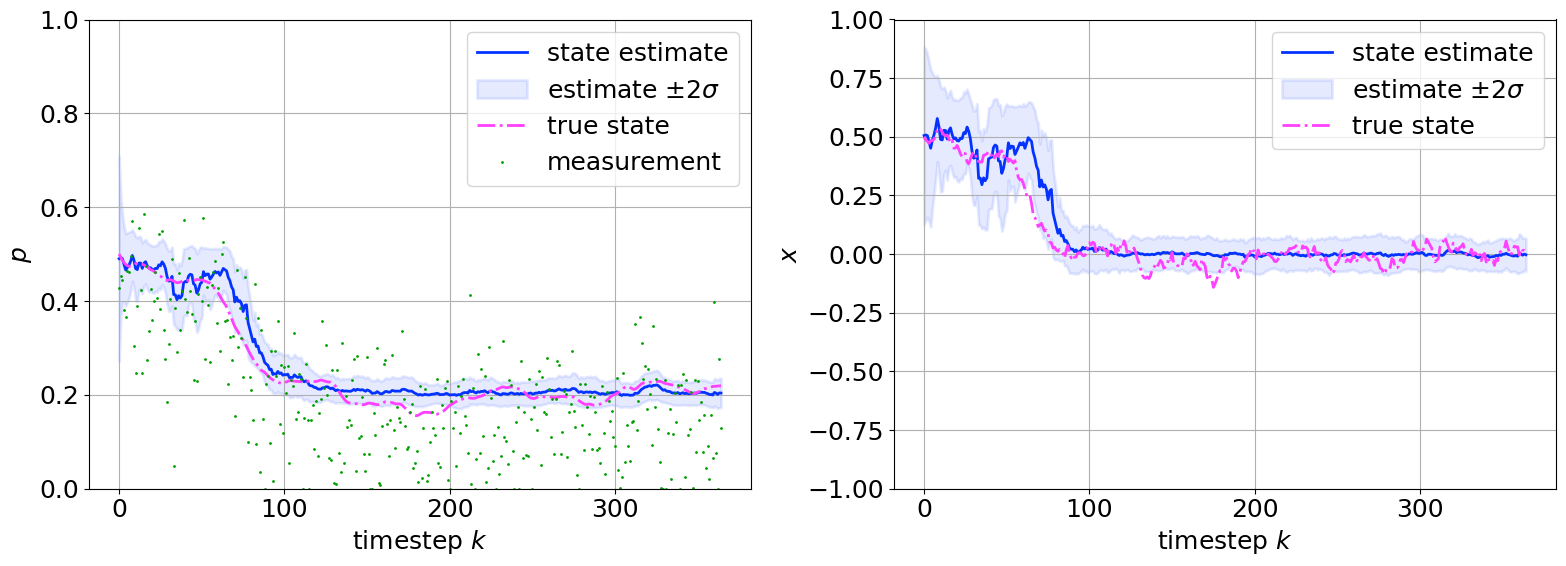

0.13424657534246576


In [6]:
# ── Estimator plots ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.subplots_adjust(wspace=0.3)

plot_estimator(t, yhat[0, :], Phat[0, 0, :], y_true[0, :],
               plot_type='state', z=z, ax=axes2[0])
axes2[0].set_ylabel(r'$p$')
axes2[0].set_ylim(0,1)

plot_estimator(t, yhat[1, :], Phat[1, 1, :], y_true[1, :],
               plot_type='state', ax=axes2[1])
axes2[1].set_ylabel(r'$x$')
axes2[1].set_ylim(-1,1)

plt.tight_layout()

plt.show()

print(percent_out(t, yhat[0, :], Phat[0, 0, :], y_true[0, :]))

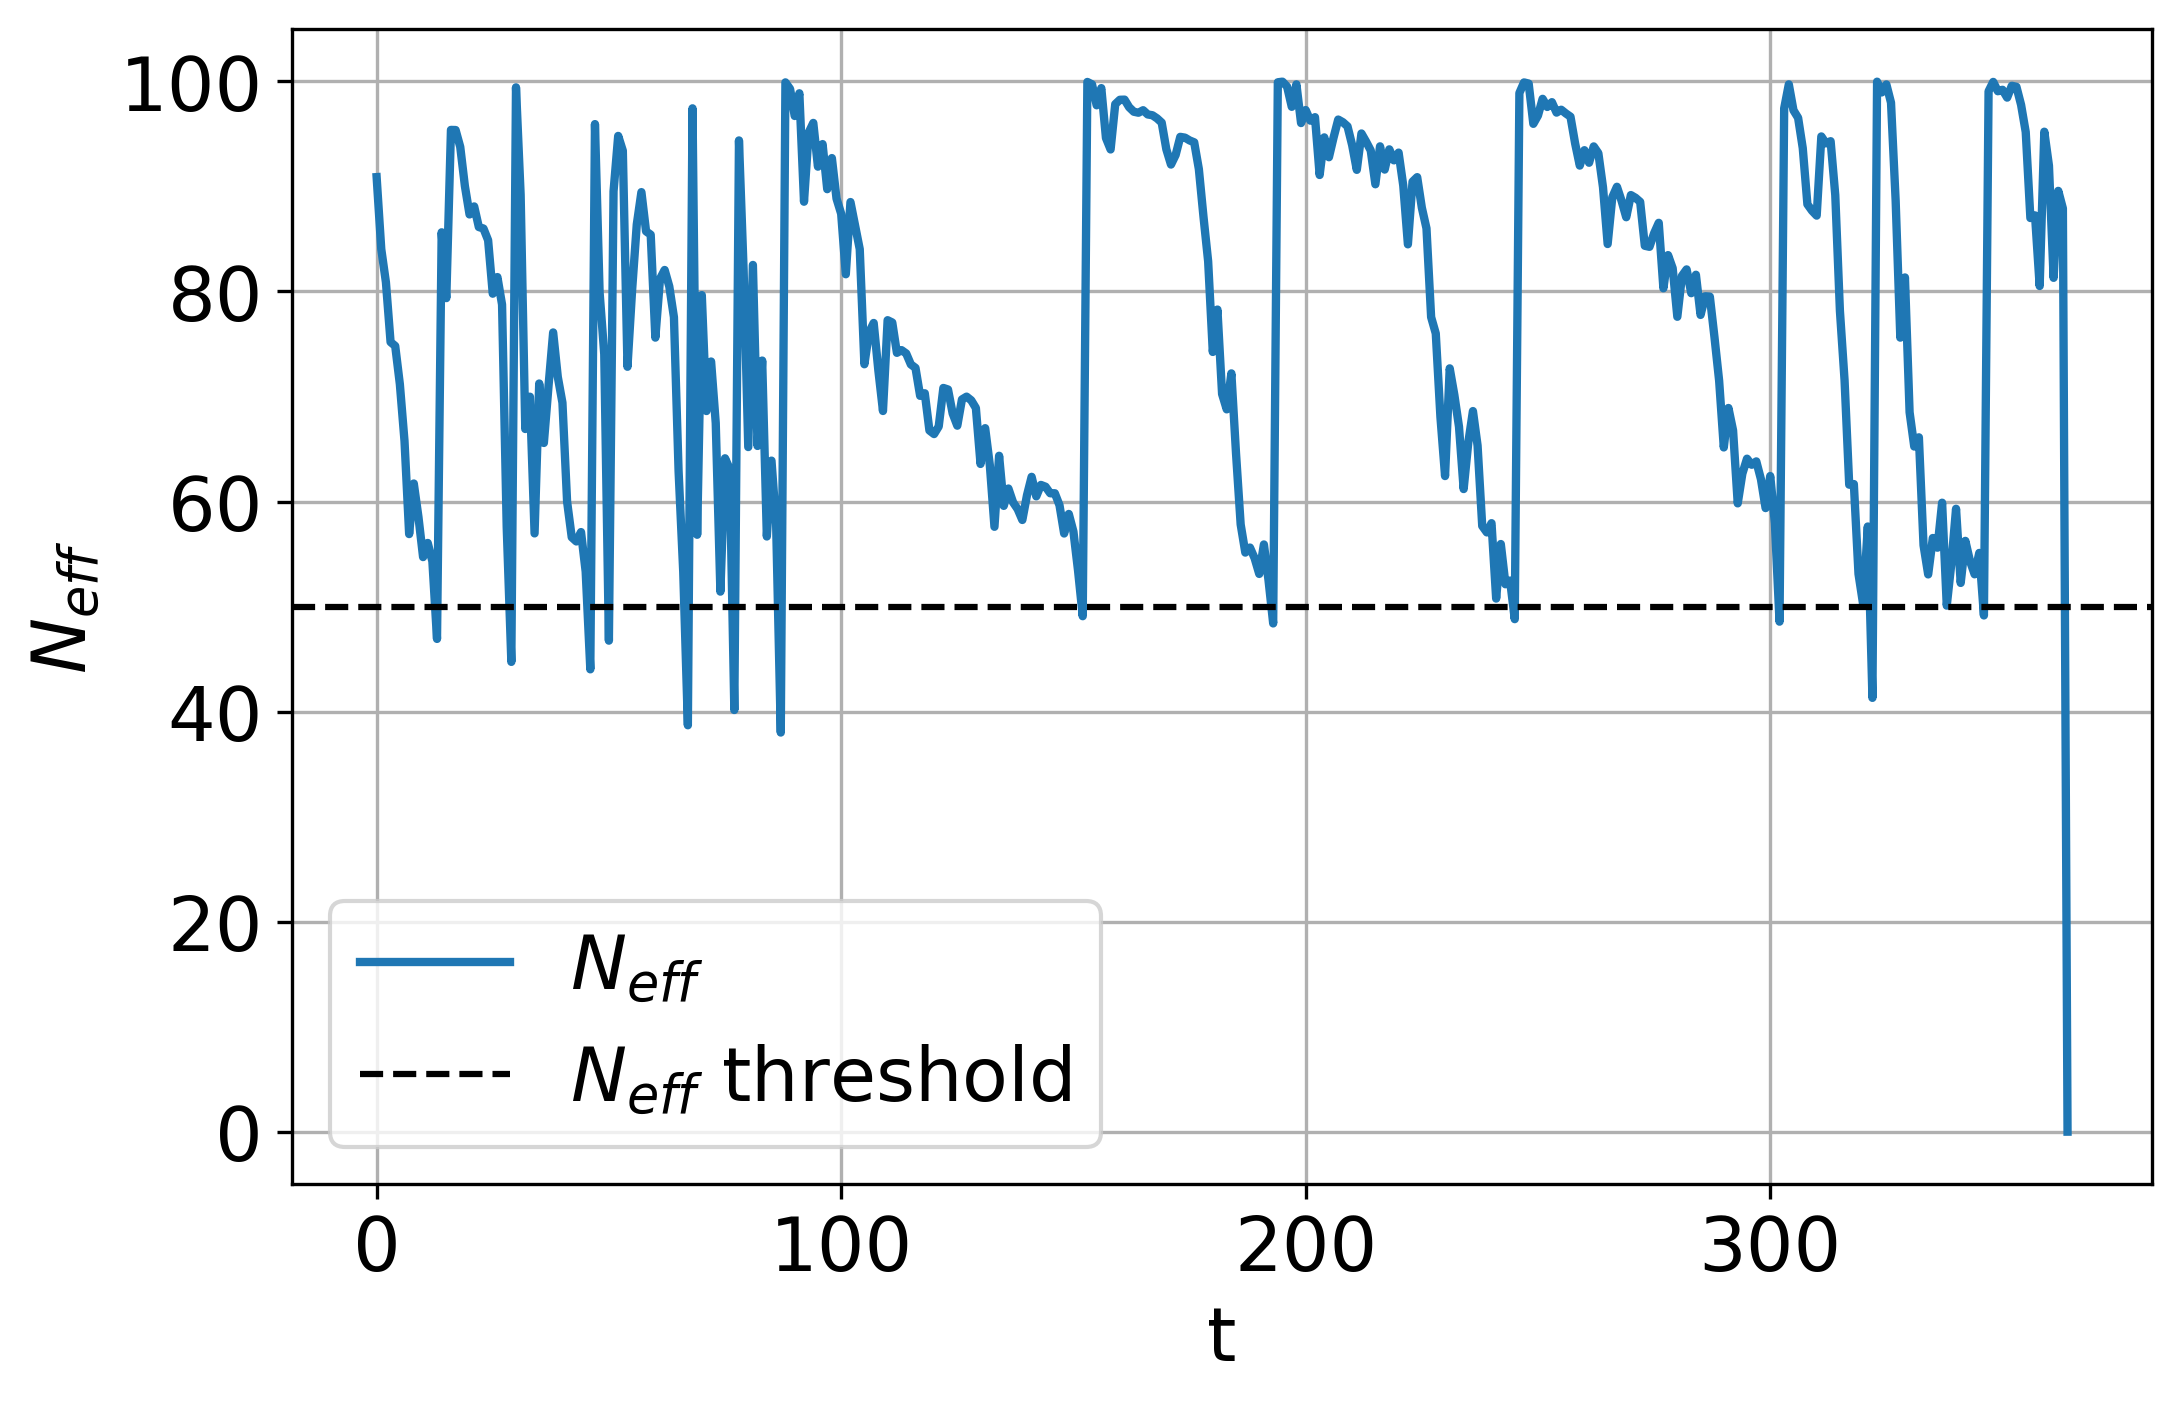

In [7]:
# plot number of effective particles
plt.figure(figsize = (8,5),dpi=300)
plt.plot(t,Neff,label= r"$N_{eff}$",lw = 2)
plt.axhline(Neff_thresh, linestyle = "dashed",color = "black", label = r"$N_{eff}$ threshold")
plt.xlabel("t")
plt.ylabel(r"$N_{eff}$")
plt.legend()
plt.grid()
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


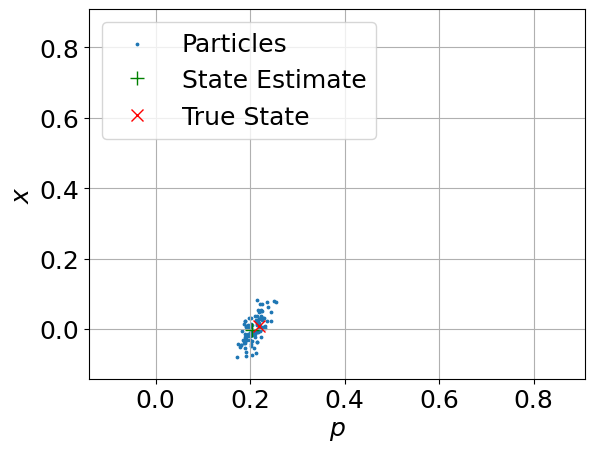

In [8]:
fig, ax = plt.subplots()

# particle scatter
scat = ax.scatter(Y_part[0, :, 0], Y_part[1, :, 0],label = "Particles",marker = "o",s = 3)

# state estimate marker
est_pt, = ax.plot([], [], marker='+', color='green', markersize=10, linestyle='None',label= "State Estimate")

# true state marker
true_pt, = ax.plot([], [], marker='x', color='red', markersize=9, linestyle='None',label= "True State")

ax.legend(loc = "upper left")
ax.set_xlabel(r"$p$")
ax.set_ylabel(r"$x$")
ax.grid()

# Axis limits
ax.set_xlim(np.min(Y_part), np.max(Y_part))
ax.set_ylim(np.min(Y_part), np.max(Y_part))

def update(k):
    pts = Y_part[:, :, k].T
    scat.set_offsets(pts)
    
    true_pt.set_data([y_true[0, k]], [y_true[1, k]])
    est_pt.set_data([yhat[0, k]], [yhat[1, k]])
    
    return scat, true_pt

ani = FuncAnimation(fig, update, frames=range(0,Y_part.shape[2],2), interval=1)
ani.save("animation.gif",dpi=200)

plt.show()

# adding noise to $\bar\beta$

set average of beta to just above middle bifurcation point. 

In [9]:
rng = np.random.default_rng(10)

def predict_state_SIS_NOD_beta(Yk, Wk, betak,delta,kp,kx,u0,tau, dt):
    nx, N = Yk.shape
    Ykp1 = np.zeros_like(Yk)

    for i in range(N):
        y0 = Yk[:, i]
        w  = Wk[0, i]
        beta = betak[0,i]
        
        sol = solve_ivp(
            SIS_NOD,
            [0, dt],
            y0,
            args = (beta,delta,kp,kx,u0,tau,w),
            method='LSODA'
        )

        Ykp1[:, i] = sol.y[:, -1]
        Ykp1[0, i] = np.clip(Ykp1[0, i], 0, 1) # keep everything bounded (try outside of ODE)
        Ykp1[1, i] = np.clip(Ykp1[1, i], -1, 1)

    return Ykp1


tspan = [0,365]
dt = 1.0
t_eval = np.arange(tspan[0],tspan[1],dt)
t = t_eval
tf = t[-1]
nt = len(t)


beta = np.copy(bp2) + 0.015

# Process noise

wstd = 0.02
Qc = wstd**2 # sqrt of this is sigma/std of w
w = rng.standard_normal(nt) * np.sqrt(Qc*dt)

betastd = 0.04
Qbc = betastd**2
betas = rng.standard_normal(nt) * np.sqrt(Qbc*dt) + beta

# Simulate dynamics
y0 = [0.7,0.7]
ny = 2
y_true = np.zeros((ny, nt))
y_true[:, 0] = y0

for k in range(nt - 1):
    y_init = y_true[:, k]
    wk = w[k]
    beta_current = betas[k]
    tspan_small = [t[k], t[k + 1]]
    sol = solve_ivp(SIS_NOD, tspan_small, y_init, args=(beta_current,delta,kp,kx,u0,tau,wk), method='LSODA')
    y_true[:, k + 1] = sol.y[:, -1]
    y_true[0,k+1] = np.clip(y_true[0,k+1],0,1)
    y_true[1,k+1] = np.clip(y_true[1,k+1],-1,1)

# Noisy measurements
vstd = 0.1
R = vstd**2 # sqrt of this is sigma of v
mu = -0.05
v = np.sqrt(R) * rng.standard_normal(nt) + mu
z = y_true[0, :] + v
# restrict to domain of problem
z[z<0]=0
z[z>1]=1


H = np.array([[1, 0]])

# Initialization
twosigp = 0.2 # 2 vstd initialization for proportion infected
twosigx = 0.4 # " for opinion state
sigpsq = (twosigp/2)**2
sigxsq = (twosigx/2)**2
P0 = np.diag([sigpsq,sigxsq]) # initial convariance

N_part = 100
Neff_thresh = int(N_part//2)
Y_part = np.zeros((2,N_part,nt))
Y_part[:, :, 0] = rng.multivariate_normal(y0, P0, N_part).T

W0 = np.ones(N_part) / N_part            # uniform initial weights
W  = np.zeros((nt, N_part))
W[0, :] = W0


# =============================================================================
# Initial weighted-sample estimate and covariance
# =============================================================================

yhat = np.zeros((ny, nt))
yhat[:, 0] = (W0 * Y_part[:, :, 0]).sum(axis=1)

Err0 = Y_part[:, :, 0] - yhat[:, 0:1]
Phat = np.zeros((ny, ny, nt))
Phat[:, :, 0] = (Err0 * W0) @ Err0.T

Neff    = np.zeros(nt)
Neff[0] = N_part
Wk      = W0.copy()
CDF     = np.cumsum(Wk)
L       = np.zeros(N_part)
R_inv   = 1/R
nw = 1


# =============================================================================
# Run particle filter
# =============================================================================


for k in range(nt - 1):

    Y_prior = Y_part[:, :, k]

    # ------------------------------------------------------------------
    # PREDICTION STEP
    # ------------------------------------------------------------------

    W_part = np.sqrt(Qc*dt)*rng.standard_normal((1, N_part))
    betak = np.sqrt(Qbc*dt)*rng.standard_normal((1, N_part)) + beta
    Y_pred = predict_state_SIS_NOD_beta(Y_prior, W_part, betak,delta,kp,kx,u0,tau, dt)

    # ------------------------------------------------------------------
    # UPDATE STEP
    # ------------------------------------------------------------------
    z_current = z[k + 1]
    Z_hat     = H @ Y_pred         # estimated measurements 
    Inn = z_current - Z_hat              # innovations 



    # Likelihood weighting for each particle
    for ip in range(N_part):
        inn_ip = (z_current - Z_hat[:, ip] - mu) # subract off the mean
        L[ip]  = np.exp(-0.5 * R_inv * inn_ip @ inn_ip)
        

    # Update weights
    Wk_unnorm = W[k, :] * L
    Wk        = Wk_unnorm / Wk_unnorm.sum()
    CDF       = np.cumsum(Wk) / Wk.sum()

    # ------------------------------------------------------------------
    # RESAMPLING
    # ------------------------------------------------------------------
    Neff[k] = 1.0 / (Wk @ Wk)    # effective number of particles

    if Neff[k] < Neff_thresh:
        CDF      = np.cumsum(Wk) / Wk.sum()
        CDF_plus = CDF + rng.uniform(0, 1e-6, N_part)  # jitter for zero-weight particles
        iSelect  = rng.uniform(0, 1, N_part)
        iNextGen = np.clip(np.searchsorted(CDF_plus, iSelect), 0, N_part - 1)
        Y_part[:, :, k + 1] = Y_pred[:, iNextGen]
        W[k + 1, :]          = np.ones(N_part) / N_part
        Wk_plot              = np.ones(N_part) / N_part
    else:
        Y_part[:, :, k + 1] = Y_pred
        W[k + 1, :]          = Wk
        Wk_plot              = Wk

    # Weighted mean estimate and sample covariance
    yhat[:, k + 1]    = (Wk_plot * Y_part[:, :, k + 1]).sum(axis=1)
    Err                = Y_part[:, :, k + 1] - yhat[:, k + 1:k + 2]
    Phat[:, :, k + 1] = (Err * Wk_plot) @ Err.T

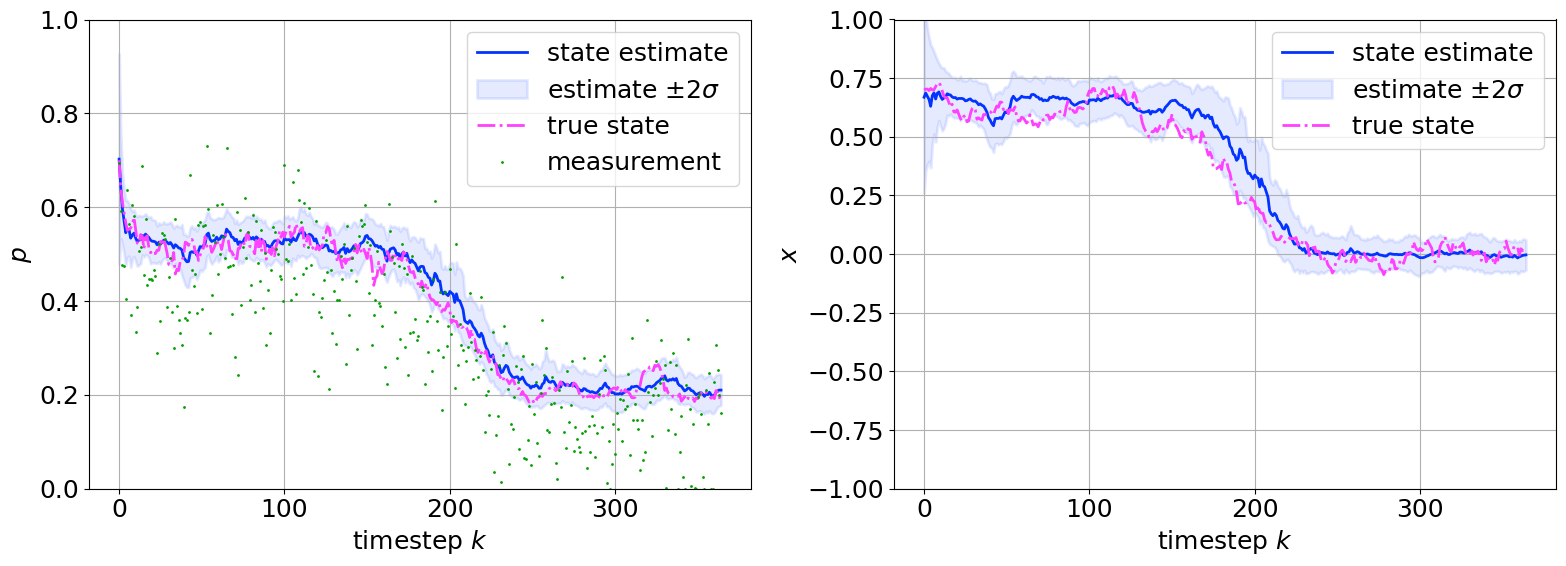

0.052054794520547946


In [10]:
# ── Estimator plots ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.subplots_adjust(wspace=0.3)

plot_estimator(t, yhat[0, :], Phat[0, 0, :], y_true[0, :],
               plot_type='state', z=z, ax=axes2[0])
axes2[0].set_ylabel(r'$p$')
axes2[0].set_ylim(0,1)
#axes2[0]

plot_estimator(t, yhat[1, :], Phat[1, 1, :], y_true[1, :],
               plot_type='state', ax=axes2[1])
axes2[1].set_ylabel(r'$x$')
axes2[1].set_ylim(-1,1)

plt.tight_layout()

plt.show()

print(percent_out(t, yhat[0, :], Phat[0, 0, :], y_true[0, :]))


MovieWriter ffmpeg unavailable; using Pillow instead.


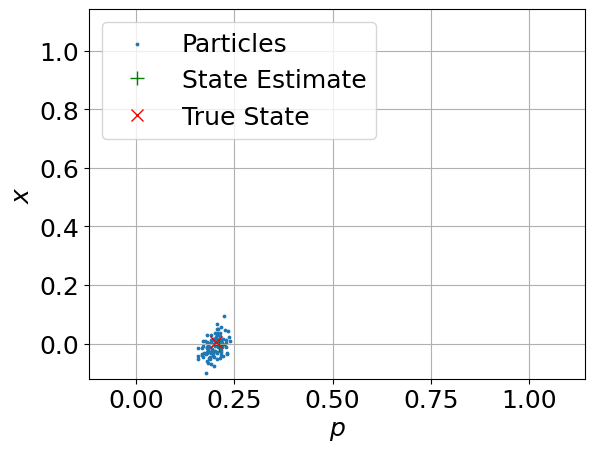

In [11]:
fig, ax = plt.subplots()

# particle scatter
scat = ax.scatter(Y_part[0, :, 0], Y_part[1, :, 0],label = "Particles",marker = "o",s = 3)

# state estimate marker
est_pt, = ax.plot([], [], marker='+', color='green', markersize=10, linestyle='None',label= "State Estimate")

# true state marker
true_pt, = ax.plot([], [], marker='x', color='red', markersize=9, linestyle='None',label= "True State")

ax.legend(loc = "upper left")
ax.set_xlabel(r"$p$")
ax.set_ylabel(r"$x$")
ax.grid()

# Axis limits
ax.set_xlim(np.min(Y_part), np.max(Y_part))
ax.set_ylim(np.min(Y_part), np.max(Y_part))

def update(k):
    pts = Y_part[:, :, k].T
    scat.set_offsets(pts)
    
    true_pt.set_data([y_true[0, k]], [y_true[1, k]])
    est_pt.set_data([yhat[0, k]], [yhat[1, k]])
    
    return scat, true_pt

ani = FuncAnimation(fig, update, frames=range(0,Y_part.shape[2],2), interval=1)
ani.save("animation.gif",dpi=200)

plt.show()

# same but with measurement of $x$

Same exact true state but now using very noisy measurement of opinion state instead of measurement of p

In [12]:
rng = np.random.default_rng(10)

# Noisy measurements
vstd = 0.5
R = vstd**2 
v = np.sqrt(R) * rng.standard_normal(nt)
z = y_true[1, :] + v

z[z>1] = 1
z[z<-1] = -1

H = np.array([[0, 1]])

# Initialization
twosigp = 0.2 # 2 vstd initialization for proportion infected
twosigx = 0.5 # " for opinion state
sigpsq = (twosigp/2)**2
sigxsq = (twosigx/2)**2
P0 = np.diag([sigpsq,sigxsq]) # initial convariance

N_part = 100
Neff_thresh = int(N_part//2)
Y_part = np.zeros((2,N_part,nt))
Y_part[:, :, 0] = rng.multivariate_normal(y0, P0, N_part).T

W0 = np.ones(N_part) / N_part            # uniform initial weights
W  = np.zeros((nt, N_part))
W[0, :] = W0


# =============================================================================
# Initial weighted-sample estimate and covariance
# =============================================================================

yhat = np.zeros((ny, nt))
yhat[:, 0] = (W0 * Y_part[:, :, 0]).sum(axis=1)

Err0 = Y_part[:, :, 0] - yhat[:, 0:1]
Phat = np.zeros((ny, ny, nt))
Phat[:, :, 0] = (Err0 * W0) @ Err0.T

Neff    = np.zeros(nt)
Neff[0] = N_part
Wk      = W0.copy()
CDF     = np.cumsum(Wk)
L       = np.zeros(N_part)
R_inv   = 1/R
nw = 1


# =============================================================================
# Run particle filter
# =============================================================================


for k in range(nt - 1):

    Y_prior = Y_part[:, :, k]

    # ------------------------------------------------------------------
    # PREDICTION STEP
    # ------------------------------------------------------------------

    W_part = np.sqrt(Qc*dt)*rng.standard_normal((1, N_part))
    betak = np.sqrt(Qbc*dt)*rng.standard_normal((1, N_part)) + beta
    Y_pred = predict_state_SIS_NOD_beta(Y_prior, W_part, betak,delta,kp,kx,u0,tau, dt)

    # ------------------------------------------------------------------
    # UPDATE STEP
    # ------------------------------------------------------------------
    z_current = z[k + 1]
    Z_hat     = H @ Y_pred         # estimated measurements 
    Inn = z_current - Z_hat              # innovations 



    # Likelihood weighting for each particle
    for ip in range(N_part):
        inn_ip = (z_current - Z_hat[:, ip]) # subract off the mean
        L[ip]  = np.exp(-0.5 * R_inv * inn_ip @ inn_ip)
        

    # Update weights
    Wk_unnorm = W[k, :] * L
    Wk        = Wk_unnorm / Wk_unnorm.sum()
    CDF       = np.cumsum(Wk) / Wk.sum()

    # ------------------------------------------------------------------
    # RESAMPLING
    # ------------------------------------------------------------------
    Neff[k] = 1.0 / (Wk @ Wk)    # effective number of particles

    if Neff[k] < Neff_thresh:
        CDF      = np.cumsum(Wk) / Wk.sum()
        CDF_plus = CDF + rng.uniform(0, 1e-6, N_part)  # jitter for zero-weight particles
        iSelect  = rng.uniform(0, 1, N_part)
        iNextGen = np.clip(np.searchsorted(CDF_plus, iSelect), 0, N_part - 1)
        Y_part[:, :, k + 1] = Y_pred[:, iNextGen]
        W[k + 1, :]          = np.ones(N_part) / N_part
        Wk_plot              = np.ones(N_part) / N_part
    else:
        Y_part[:, :, k + 1] = Y_pred
        W[k + 1, :]          = Wk
        Wk_plot              = Wk

    # Weighted mean estimate and sample covariance
    yhat[:, k + 1]    = (Wk_plot * Y_part[:, :, k + 1]).sum(axis=1)
    Err                = Y_part[:, :, k + 1] - yhat[:, k + 1:k + 2]
    Phat[:, :, k + 1] = (Err * Wk_plot) @ Err.T

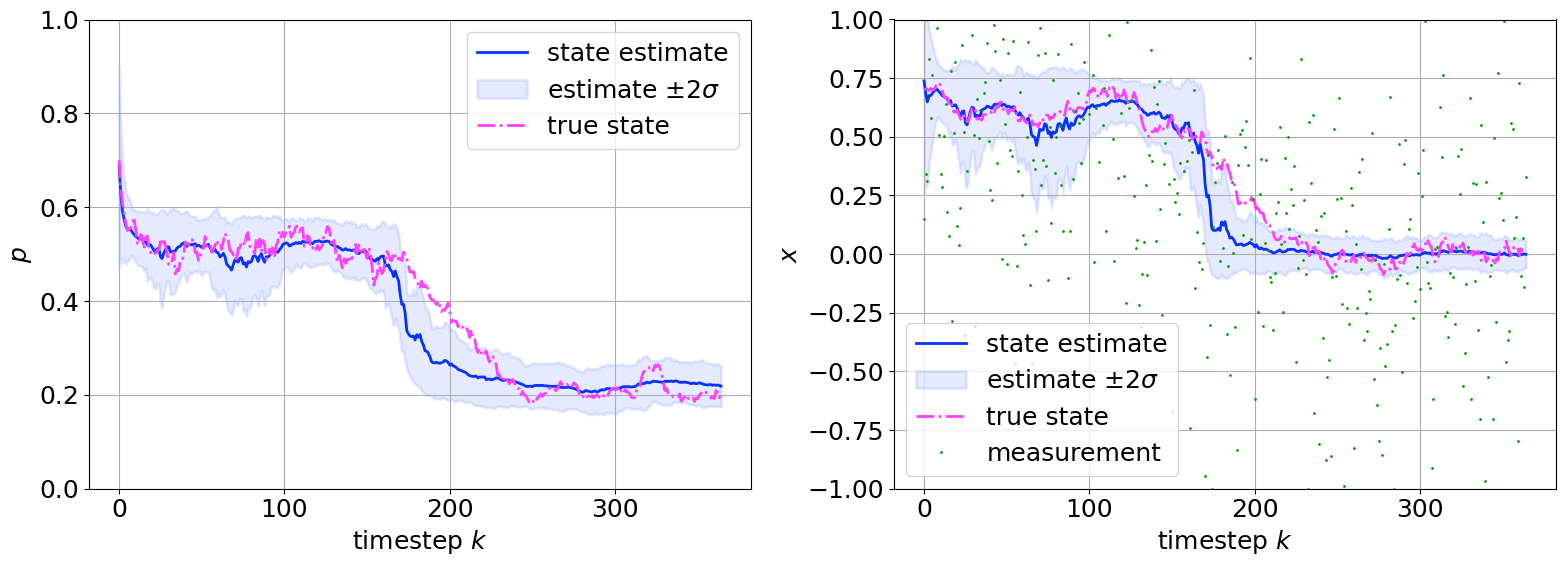

0.1232876712328767


In [13]:
# ── Estimator plots ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.subplots_adjust(wspace=0.3)

plot_estimator(t, yhat[0, :], Phat[0, 0, :], y_true[0, :],
               plot_type='state', ax=axes2[0])
axes2[0].set_ylabel(r'$p$')
axes2[0].set_ylim(0,1)
#axes2[0]

plot_estimator(t, yhat[1, :], Phat[1, 1, :], y_true[1, :],
               plot_type='state',z=z ,ax=axes2[1])
axes2[1].set_ylabel(r'$x$')
axes2[1].set_ylim(-1,1)
plt.tight_layout()

plt.show()
print(percent_out(t, yhat[0, :], Phat[0, 0, :], y_true[0, :]))

# Back to $p$ measurement but only one measurement a week

In [14]:
rng = np.random.default_rng(10)

beta = np.copy(bp2) + 0.015

# Noisy measurements
vstd = 0.1
R = vstd**2 # sqrt of this is sigma of v
mu = -0.05
v = np.sqrt(R) * rng.standard_normal(nt) + mu
z = y_true[0, :] + v
# restrict to domain of problem
z[z<0]=0
z[z>1]=1

H = np.array([[1, 0]])

# Initialization
twosigp = 0.2 # 2 vstd initialization for proportion infected
twosigx = 0.4 # " for opinion state
sigpsq = (twosigp/2)**2
sigxsq = (twosigx/2)**2
P0 = np.diag([sigpsq,sigxsq]) # initial convariance

N_part = 100
Neff_thresh = int(N_part//2)
Y_part = np.zeros((2,N_part,nt))
Y_part[:, :, 0] = rng.multivariate_normal(y0, P0, N_part).T

W0 = np.ones(N_part) / N_part            # uniform initial weights
W  = np.zeros((nt, N_part))
W[0, :] = W0


# =============================================================================
# Initial weighted-sample estimate and covariance
# =============================================================================

yhat = np.zeros((ny, nt))
yhat[:, 0] = (W0 * Y_part[:, :, 0]).sum(axis=1)

Err0 = Y_part[:, :, 0] - yhat[:, 0:1]
Phat = np.zeros((ny, ny, nt))
Phat[:, :, 0] = (Err0 * W0) @ Err0.T

Neff    = np.zeros(nt)
Neff[0] = N_part
Wk      = W0.copy()
CDF     = np.cumsum(Wk)
L       = np.zeros(N_part)
R_inv   = 1/R
nw = 1

msmt_interval = 7


# =============================================================================
# Run particle filter
# =============================================================================


for k in range(nt - 1):

    Y_prior = Y_part[:, :, k]

    # ------------------------------------------------------------------
    # PREDICTION STEP
    # ------------------------------------------------------------------

    W_part = np.sqrt(Qc*dt)*rng.standard_normal((1, N_part))
    betak = np.sqrt(Qbc*dt)*rng.standard_normal((1, N_part)) + beta
    Y_pred = predict_state_SIS_NOD_beta(Y_prior, W_part, betak,delta,kp,kx,u0,tau, dt)

    # ------------------------------------------------------------------
    # UPDATE STEP
    # ------------------------------------------------------------------

    if (k + 1) % msmt_interval == 0:
        # -------------------------
        # MEASUREMENT UPDATE
        # -------------------------
        z_current = z[k + 1]

        Z_hat = H @ Y_pred

        for ip in range(N_part):
            inn_ip = (z_current - Z_hat[:, ip] - mu)
            L[ip]  = np.exp(-0.5 * R_inv * inn_ip @ inn_ip)

        # Update weights
        Wk_unnorm = W[k, :] * L
        Wk        = Wk_unnorm / Wk_unnorm.sum()

        # ------------------------------------------------------------------
        # RESAMPLING
        # ------------------------------------------------------------------
        Neff[k] = 1.0 / (Wk @ Wk)    # effective number of particles

        if Neff[k] < Neff_thresh:
            CDF      = np.cumsum(Wk) / Wk.sum()
            CDF_plus = CDF + rng.uniform(0, 1e-6, N_part)  # jitter for zero-weight particles
            iSelect  = rng.uniform(0, 1, N_part)
            iNextGen = np.clip(np.searchsorted(CDF_plus, iSelect), 0, N_part - 1)
            Y_part[:, :, k + 1] = Y_pred[:, iNextGen]
            W[k + 1, :]          = np.ones(N_part) / N_part
            Wk_plot              = np.ones(N_part) / N_part
        else:
            Y_part[:, :, k + 1] = Y_pred
            W[k + 1, :]          = Wk
            Wk_plot              = Wk

    else:
        #predict only
        Y_part[:, :, k + 1] = Y_pred

        # weights unchanged
        W[k + 1, :] = W[k, :]
        Wk_plot     = W[k, :]

        Neff[k] = 1.0 / (Wk_plot @ Wk_plot)


    # Weighted mean estimate and sample covariance
    yhat[:, k + 1]    = (Wk_plot * Y_part[:, :, k + 1]).sum(axis=1)
    Err                = Y_part[:, :, k + 1] - yhat[:, k + 1:k + 2]
    Phat[:, :, k + 1] = (Err * Wk_plot) @ Err.T

0.1232876712328767


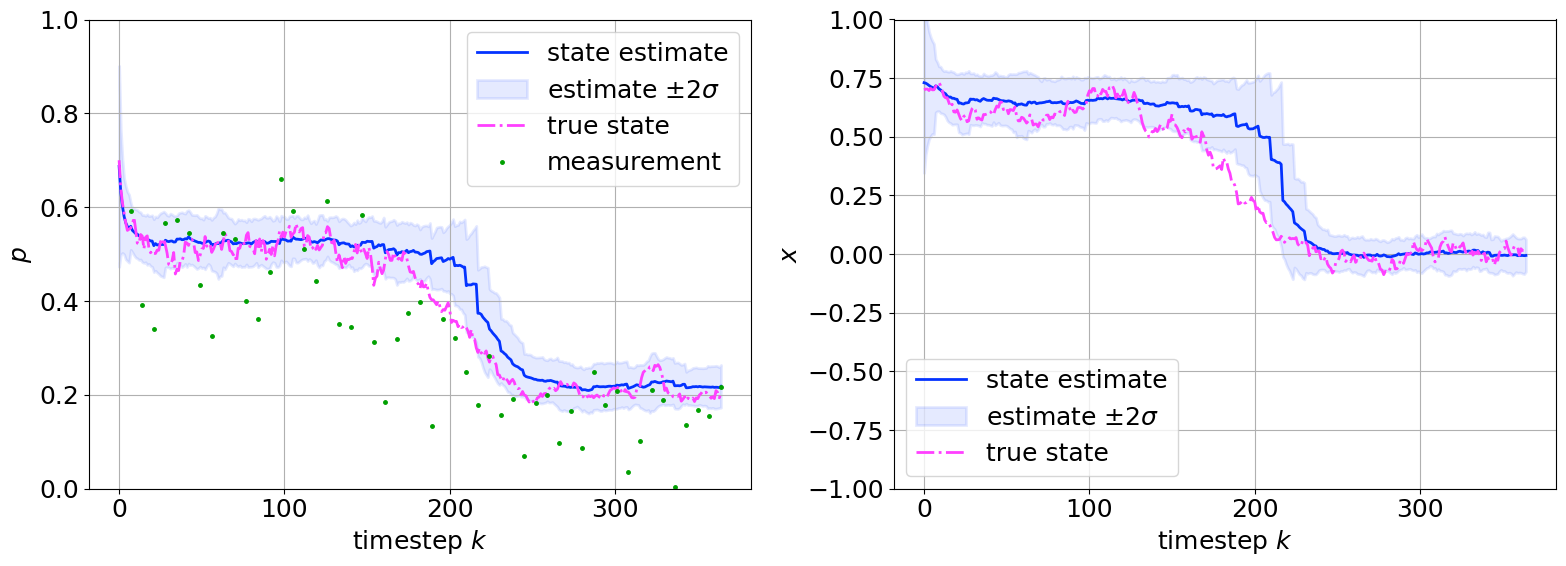

In [15]:
msmt_indexes = np.arange(1, nt)[np.arange(1, nt) % msmt_interval == 0]

# ── Estimator plots ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.subplots_adjust(wspace=0.3)

plot_estimator(t, yhat[0, :], Phat[0, 0, :], y_true[0, :],
               plot_type='state', ax=axes2[0])
axes2[0].set_ylabel(r'$p$')
axes2[0].set_ylim(0,1)
axes2[0].plot(msmt_indexes,z[msmt_indexes], ".", color = MCcolors["green"],markersize =5,label = "measurement")
axes2[0].legend()

plot_estimator(t, yhat[1, :], Phat[1, 1, :], y_true[1, :],
               plot_type='state', ax=axes2[1])
axes2[1].set_ylabel(r'$x$')
axes2[1].set_ylim(-1,1)

plt.tight_layout()
print(percent_out(t, yhat[0, :], Phat[0, 0, :], y_true[0, :]))

# sweeping through increasing $\bar\beta$ values

In [16]:
rng = np.random.default_rng(10)

tspan = [0,500]
dt = 1.0
t_eval = np.arange(tspan[0],tspan[1],dt)
t = t_eval
tf = t[-1]
nt = len(t)

# Process noise

wstd = 0.02
Qc = wstd**2 # sqrt of this is sigma/std of w
w = rng.standard_normal(nt) * np.sqrt(Qc*dt)

# beta values to sweep over
betas = np.linspace(0.1,1.0,nt)

# Simulate dynamics
y0 = [0.1,0.1]
ny = 2
y_true = np.zeros((ny, nt))
y_true[:, 0] = y0

for k in range(nt - 1):
    y_init = y_true[:, k]
    wk = w[k]
    beta_current = betas[k]
    tspan_small = [t[k], t[k + 1]]
    sol = solve_ivp(SIS_NOD, tspan_small, y_init, args=(beta_current,delta,kp,kx,u0,tau,wk), method='LSODA')
    y_true[:, k + 1] = sol.y[:, -1]
    y_true[0,k+1] = np.clip(y_true[0,k+1],0,1)
    y_true[1,k+1] = np.clip(y_true[1,k+1],-1,1)

# Noisy measurements
vstd = 0.1
R = vstd**2 # sqrt of this is sigma of v
mu = -0.05
v = np.sqrt(R) * rng.standard_normal(nt) + mu
z = y_true[0, :] + v
# restrict to domain of problem
z[z<0]=0
z[z>1]=1


H = np.array([[1, 0]])

# Initialization
twosigp = 0.2 # 2 vstd initialization for proportion infected
twosigx = 0.4 # " for opinion state
sigpsq = (twosigp/2)**2
sigxsq = (twosigx/2)**2
P0 = np.diag([sigpsq,sigxsq]) # initial convariance

N_part = 100
Neff_thresh = int(N_part//2)
Y_part = np.zeros((2,N_part,nt))
Y_part[:, :, 0] = rng.multivariate_normal(y0, P0, N_part).T

W0 = np.ones(N_part) / N_part            # uniform initial weights
W  = np.zeros((nt, N_part))
W[0, :] = W0


# =============================================================================
# Initial weighted-sample estimate and covariance
# =============================================================================

yhat = np.zeros((ny, nt))
yhat[:, 0] = (W0 * Y_part[:, :, 0]).sum(axis=1)

Err0 = Y_part[:, :, 0] - yhat[:, 0:1]
Phat = np.zeros((ny, ny, nt))
Phat[:, :, 0] = (Err0 * W0) @ Err0.T

Neff    = np.zeros(nt)
Neff[0] = N_part
Wk      = W0.copy()
CDF     = np.cumsum(Wk)
L       = np.zeros(N_part)
R_inv   = 1/R
nw = 1


# =============================================================================
# Run particle filter
# =============================================================================


for k in range(nt - 1):

    Y_prior = Y_part[:, :, k]

    # ------------------------------------------------------------------
    # PREDICTION STEP
    # ------------------------------------------------------------------

    W_part = np.sqrt(Qc*dt)*rng.standard_normal((1, N_part))
    #betak = np.sqrt(Qbc*dt)*rng.standard_normal((1, N_part)) + beta
    betak = betas[k]
    Y_pred = predict_state_SIS_NOD(Y_prior, W_part, betak,delta,kp,kx,u0,tau, dt)

    # ------------------------------------------------------------------
    # UPDATE STEP
    # ------------------------------------------------------------------
    z_current = z[k + 1]
    Z_hat     = H @ Y_pred         # estimated measurements 
    Inn = z_current - Z_hat              # innovations 



    # Likelihood weighting for each particle
    for ip in range(N_part):
        inn_ip = (z_current - Z_hat[:, ip] - mu) # subract off the mean
        L[ip]  = np.exp(-0.5 * R_inv * inn_ip @ inn_ip)
        

    # Update weights
    Wk_unnorm = W[k, :] * L
    Wk        = Wk_unnorm / Wk_unnorm.sum()
    CDF       = np.cumsum(Wk) / Wk.sum()

    # ------------------------------------------------------------------
    # RESAMPLING
    # ------------------------------------------------------------------
    Neff[k] = 1.0 / (Wk @ Wk)    # effective number of particles

    if Neff[k] < Neff_thresh:
        CDF      = np.cumsum(Wk) / Wk.sum()
        CDF_plus = CDF + rng.uniform(0, 1e-6, N_part)  # jitter for zero-weight particles
        iSelect  = rng.uniform(0, 1, N_part)
        iNextGen = np.clip(np.searchsorted(CDF_plus, iSelect), 0, N_part - 1)
        Y_part[:, :, k + 1] = Y_pred[:, iNextGen]
        W[k + 1, :]          = np.ones(N_part) / N_part
        Wk_plot              = np.ones(N_part) / N_part
    else:
        Y_part[:, :, k + 1] = Y_pred
        W[k + 1, :]          = Wk
        Wk_plot              = Wk

    # Weighted mean estimate and sample covariance
    yhat[:, k + 1]    = (Wk_plot * Y_part[:, :, k + 1]).sum(axis=1)
    Err                = Y_part[:, :, k + 1] - yhat[:, k + 1:k + 2]
    Phat[:, :, k + 1] = (Err * Wk_plot) @ Err.T

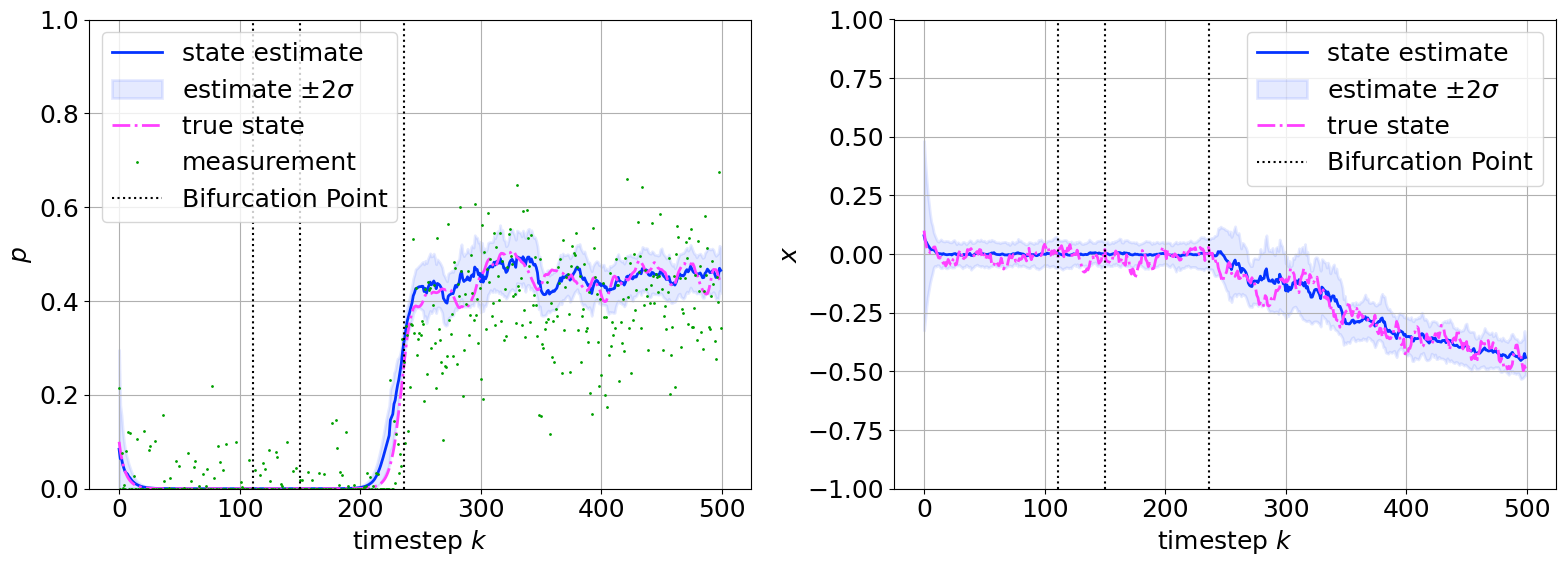

0.078


In [17]:
# ── Estimator plots ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.subplots_adjust(wspace=0.3)

plot_estimator(t, yhat[0, :], Phat[0, 0, :], y_true[0, :],
               plot_type='state', z=z, ax=axes2[0])
axes2[0].set_ylabel(r'$p$')
axes2[0].set_ylim(0,1)
axes2[0].axvline(np.where(betas>bp1)[0][0],color = "black",label = "Bifurcation Point",linestyle = ":")
axes2[0].axvline(np.where(betas>bp2)[0][0],color = "black",linestyle = ":")
axes2[0].axvline(np.where(betas>bp3)[0][0],color = "black",linestyle = ":")
axes2[0].legend()
#axes2[0]

plot_estimator(t, yhat[1, :], Phat[1, 1, :], y_true[1, :],
               plot_type='state', ax=axes2[1])
axes2[1].set_ylabel(r'$x$')
axes2[1].set_ylim(-1,1)
axes2[1].axvline(np.where(betas>bp1)[0][0],color = "black",label = "Bifurcation Point",linestyle = ":")
axes2[1].axvline(np.where(betas>bp2)[0][0],color = "black",linestyle = ":")
axes2[1].axvline(np.where(betas>bp3)[0][0],color = "black",linestyle = ":")
axes2[1].legend()

plt.tight_layout()

plt.show()
print(percent_out(t, yhat[0, :], Phat[0, 0, :], y_true[0, :]))